<a href="https://colab.research.google.com/github/project-722007/MIC/blob/main/MIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MIC 2026 AIML Interview** #
# Track 1 - Computer Vision - Traffic Robot #


In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
# classic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 # opencv
import math

# system imports
import os
import zipfile

# keras/sklearn imports
from tensorflow.keras import layers, models
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

# global constant
IMG_SIZE = 64 # don't change

In [53]:
if __name__ == '__main__':
    zip_file_path = '/content/drive/MyDrive/mic/Vehicles.zip'
    data_dir = './data/Vehicles/Vehicles/'

    os.makedirs(data_dir, exist_ok=True)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)

    splits = ['train', 'test', 'valid']  # adjust 'valid' to match your actual folder name
    split_data = {}

    for split in splits:
        split_dir = os.path.join(data_dir, split)
        csv_path = os.path.join(split_dir, '_classes.csv')

        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns]

        filename_col = df.columns[0]
        class_cols = [c for c in df.columns[1:] if c != '0']  # drop the placeholder "0" column

        df['filepath'] = df[filename_col].apply(lambda f: os.path.join(split_dir, f))
        df['num_labels'] = df[class_cols].sum(axis=1)

        split_data[split] = df

        print(f"{split}: {len(df)} images")
        print(f"  multi-label rows: {(df['num_labels'] > 1).sum()}")
        print(f"  no-label rows: {(df['num_labels'] == 0).sum()}")

    train_df = split_data['train']
    class_cols = [c for c in train_df.columns if c not in ('filename', 'filepath', 'num_labels', '0')]

train: 4311 images
  multi-label rows: 345
  no-label rows: 405
test: 87 images
  multi-label rows: 5
  no-label rows: 4
valid: 151 images
  multi-label rows: 14
  no-label rows: 9


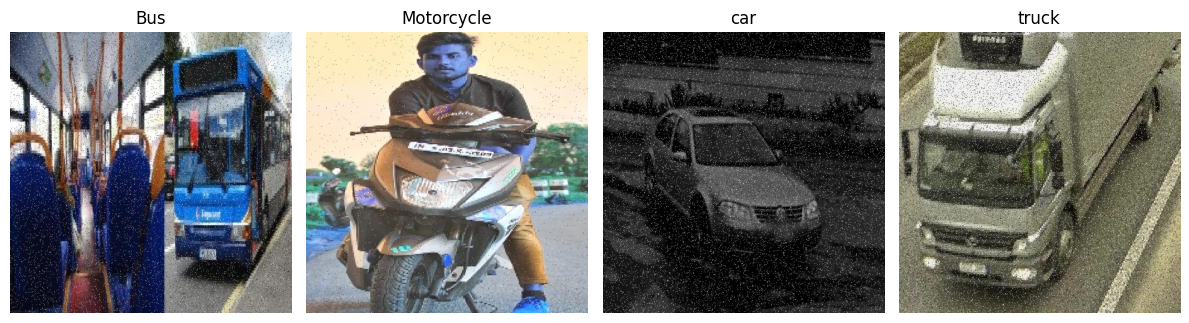

In [54]:
# Plot a sample image for each class in a single figure
if __name__ == '__main__':
    plt.figure(figsize=(12, 8))
    cols = 4
    rows = math.ceil(len(class_cols) / cols)

    for i, cls in enumerate(class_cols):
        # pick a clean example: this class = 1, and it's the only class marked
        candidates = train_df[(train_df[cls] == 1) & (train_df['num_labels'] == 1)]
        if len(candidates) == 0:
            candidates = train_df[train_df[cls] == 1]  # fallback if no clean single-label example exists

        sample_row = candidates.iloc[0]
        img = cv2.imread(sample_row['filepath'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [55]:
if __name__ == '__main__':
    for cls in class_cols:
        counts = {split: int(split_data[split][cls].sum()) for split in splits}
        print(f'{cls}: {counts}')

Bus: {'train': 987, 'test': 15, 'valid': 24}
Motorcycle: {'train': 978, 'test': 46, 'valid': 6}
car: {'train': 1269, 'test': 16, 'valid': 82}
truck: {'train': 1029, 'test': 11, 'valid': 45}


# Image Classification

In this section, we will use the augmented images to train a CNN model to predict the Pokemon class of an input image. First, we will prepare the data:
- `X` stores each image as a numpy array with the shape (IMG_SIZE, IMG_SIZE, 3).
- `y` contains the one-hot encoded labels.

Then split them into training and testing dataset.

In [56]:
def prepare_data(df, class_label_list, img_size):
    X = []
    y = []

    for _, row in df.iterrows():
        if row['num_labels'] != 1:
            continue

        img_path = row['filepath']
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0

        label_idx = class_label_list.index([c for c in class_label_list if row[c] == 1][0])

        X.append(img)
        y.append(label_idx)

    X = np.array(X)
    y = np.array(y).reshape(-1, 1)
    return X, y

In [57]:
# Prepare the dataset for image classification training
if __name__ == '__main__':
    IMG_SIZE = 64
    class_label_list = class_cols

    X_train, y_train_idx = prepare_data(split_data['train'], class_label_list, IMG_SIZE)
    X_val, y_val_idx = prepare_data(split_data['valid'], class_label_list, IMG_SIZE)
    X_test, y_test_idx = prepare_data(split_data['test'], class_label_list, IMG_SIZE)

    encoder = OneHotEncoder()
    y_train = encoder.fit_transform(y_train_idx).toarray()
    y_val = encoder.transform(y_val_idx).toarray()
    y_test = encoder.transform(y_test_idx).toarray()

    print("train:", X_train.shape, y_train.shape)
    print("val:  ", X_val.shape, y_val.shape)
    print("test: ", X_test.shape, y_test.shape)

train: (3561, 64, 64, 3) (3561, 4)
val:   (128, 64, 64, 3) (128, 4)
test:  (78, 64, 64, 3) (78, 4)


Now, it is finally time to build and train your CNN model architecture. You have the option to explore different configurations of the CNN model and evaluate its performance. However, you may only use the following 5 layers:
1. `Conv2D`: You are free to explore kernel configurations, activations, etc. [Doc.](https://keras.io/api/layers/convolution_layers/convolution2d/)
2. `MaxPooling2D`: You are free to explore the pooling size, stride, etc. [Doc.](https://keras.io/api/layers/pooling_layers/max_pooling2d/)
3. `Flatten`: Use this layer to flatten the neurons. [Doc.](https://keras.io/api/layers/reshaping_layers/flatten/)
4. `Dense`: You are free to explore the number of filters, activation functions, etc. [Doc.](https://keras.io/api/layers/core_layers/dense/)
5. `Dropout`: Choose your parameter to prevent overfitting.[Doc.](https://keras.io/api/layers/regularization_layers/dropout/)

Your model should contain at least one layer from each of the mentioned types, except for `Dropout`. The last layer should be a dense layer with 10 neurons, representing the probability of each Pokemon class.

After building your desired architecture, you need to compile the model with following parameters:
1. `optimizer`: An algorithm which updates the model's weight during training to minimize the loss function. You are free to explore different optimizers but we recommend `adam`.
2. `loss`: A mathematical function which measures how far the model's predictions are from actual labels. You are free to choose your own, but we recommend `categorical_crossentropy`.
3. metrics: evaluation measures used to assess the model performance. You are free to choose your own, but we recommend either `f1_score` or `accuracy`.

**Hint:** The model in our solution uses approximately 700,000 trainable parameters. We suggest you keep the number of trainable parameters under 1,000,000 for efficient training and to avoid overfitting.


**Task 4**: Complete the `get_cnn_model()` function

In [58]:
def get_cnn_model():
    # TODO (Task 4): Complete the CNN model architecture based on the instructions
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Stronger augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.15),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(len(class_cols), activation='softmax')
    ])

    return model
 # Replace None with the model

if __name__ == '__main__':
    cnn_model = get_cnn_model()
    cnn_model.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))
    cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 64, 64, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,756 (2.36 MB)

 Trainable params: 618,308 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

It is now time to train the CNN model you built in the previous tasks. You are free to explore different configurations of parameters. However, keep in mind that increasing the number of training epochs requires more computational resources and time, and it does not necessarily indicate better model performance due to the potential for overfitting.

**Task 5**: Train your CNN model.

In [59]:
if __name__ == '__main__':
    # TODO (Task 5): Train the CNN model. Feel free to change the codes below
    cnn_model.compile(
      optimizer='adam',
      loss='categorical_crossentropy',  # since y is one-hot encoded (from OneHotEncoder)
      metrics=['accuracy'])



    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = cnn_model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop]
    )


Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4271 - loss: 1.3220 - val_accuracy: 0.5391 - val_loss: 7.0457
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4895 - loss: 1.1483 - val_accuracy: 0.5391 - val_loss: 10.1731
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5232 - loss: 1.0835 - val_accuracy: 0.5703 - val_loss: 4.0475
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5521 - loss: 1.0609 - val_accuracy: 0.5938 - val_loss: 2.0456
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6021 - loss: 0.9737 - val_accuracy: 0.6328 - val_loss: 1.0617
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6377 - loss: 0.9150 - val_accuracy: 0.5156 - val_loss: 1.2911
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6768 - loss: 0.8025 - val_accuracy: 0.5781 - val_loss: 1.3518
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6914 - loss: 0.7825 - val_acc

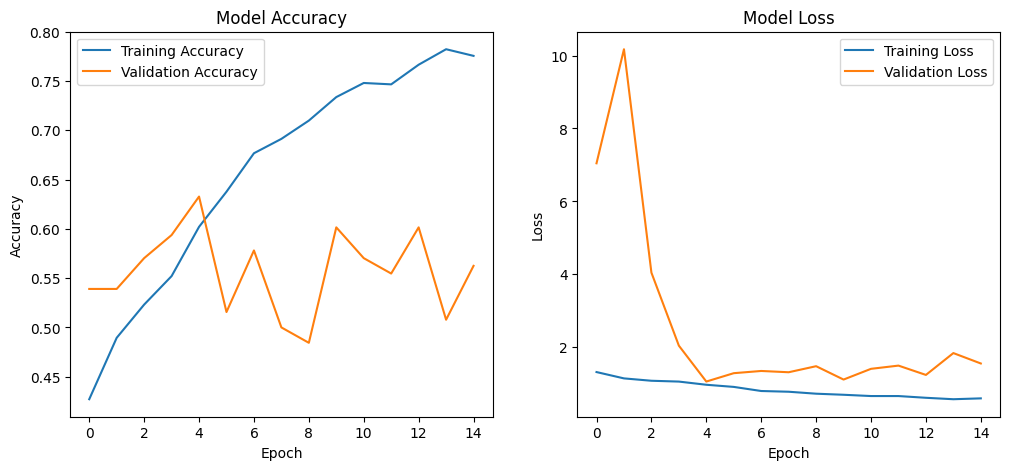

In [60]:
# Plot your CNN model's training and validation accuracy and loss curves
if __name__ == '__main__':
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

In [61]:
# Generate and display the confusion matrix
if __name__ == '__main__':
    predictions = cnn_model.predict(X_test)
    predicted_classes = np.argmax(predictions, axis=1)
    predicted_classes = [class_cols[i] for i in predicted_classes]
    true_labels = np.argmax(y_test, axis=1)
    true_labels = [class_cols[i] for i in true_labels]

    confusion_mtx = pd.crosstab(pd.Series(true_labels, name='Actual'), pd.Series(predicted_classes, name='Predicted'))
    print(confusion_mtx)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted   Bus  Motorcycle  car  truck
Actual                                 
Bus           6           0    1      5
Motorcycle    0          36    4      5
car           2           0    8      3
truck         0           1    0      7


Just for fun: Run the following cell to see if your model passes the CAPTCHA test.

Disclaimer: Please do not use AI models to bypass CAPTCHA checks in real-world scenarios, as it is unethical :P